Практическая работа 7 - Атаманчук А.В. КВБО-01-22

In [2]:
from __future__ import annotations

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)
from sklearn.decomposition import PCA

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = ARTIFACTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
LABELS_DIR = ARTIFACTS_DIR / "labels"
LABELS_DIR.mkdir(parents=True, exist_ok=True)

try:
    plt.style.use('seaborn-v0_8')
except OSError:
    try:
        plt.style.use('seaborn')
    except OSError:
        plt.style.use('default')
sns.set_palette("husl")


In [3]:
def compute_clustering_metrics(X, labels, noise_mask=None):
    """
    Вычисляет внутренние метрики качества кластеризации.
    
    Для DBSCAN с шумом (label=-1) можно исключить шумовые точки.
    """
    if noise_mask is not None:
        X_clean = X[~noise_mask]
        labels_clean = labels[~noise_mask]
    else:
        X_clean = X
        labels_clean = labels
    
    unique_labels = np.unique(labels_clean)
    if len(unique_labels) < 2:
        return {
            "silhouette": None,
            "davies_bouldin": None,
            "calinski_harabasz": None
        }
    
    metrics = {
        "silhouette": float(silhouette_score(X_clean, labels_clean)),
        "davies_bouldin": float(davies_bouldin_score(X_clean, labels_clean)),
        "calinski_harabasz": float(calinski_harabasz_score(X_clean, labels_clean))
    }
    return metrics

def plot_pca_clusters(X, labels, title="PCA Clustering", save_path=None):
    """Визуализация кластеров в 2D через PCA"""
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X)
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=30, alpha=0.6)
    plt.colorbar(scatter, label='Cluster')
    plt.xlabel(f'PC1 (explained variance: {pca.explained_variance_ratio_[0]:.2%})')
    plt.ylabel(f'PC2 (explained variance: {pca.explained_variance_ratio_[1]:.2%})')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    return pca


## Датасет 1: S07-hw-dataset-01.csv

In [4]:
df1 = pd.read_csv('data/S07-hw-dataset-01.csv')
print(f"Размер датасета: {df1.shape}")
print(f"\nПервые строки:")
df1.head()

Размер датасета: (12000, 9)

Первые строки:


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213


In [5]:
print("Информация о датасете:")
df1.info()
print("\nБазовые статистики:")
df1.describe()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB

Базовые статистики:


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,5999.50000,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,3464.24595,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,0.00000,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,2999.75000,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,5999.50000,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,8999.25000,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,11999.00000,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745


In [6]:
missing = df1.isnull().sum()
print("Пропуски:")
print(missing[missing > 0] if missing.sum() > 0 else "Пропусков нет")

sample_ids_1 = df1['sample_id'].values
X1_raw = df1.drop(columns=['sample_id']).values
print(f"\nX1_raw shape: {X1_raw.shape}")
print(f"Типы признаков: все числовые")

Пропуски:
Пропусков нет

X1_raw shape: (12000, 8)
Типы признаков: все числовые


### Препроцессинг для датасета 1

In [7]:
scaler1 = StandardScaler()
X1 = scaler1.fit_transform(X1_raw)
print(f"X1 shape после scaling: {X1.shape}")
print(f"Среднее: {X1.mean(axis=0)[:3]}...")
print(f"Стд. отклонение: {X1.std(axis=0)[:3]}...")

X1 shape после scaling: (12000, 8)
Среднее: [-7.10542736e-18 -4.05601478e-17 -7.10542736e-18]...
Стд. отклонение: [1. 1. 1.]...


### KMeans для датасета 1

In [8]:
k_range = range(2, 21)
kmeans_results_1 = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(X1)
    metrics = compute_clustering_metrics(X1, labels)
    metrics['k'] = k
    metrics['inertia'] = float(kmeans.inertia_)
    kmeans_results_1.append(metrics)

df_kmeans_1 = pd.DataFrame(kmeans_results_1)
print("Результаты KMeans:")
df_kmeans_1.head(10)

Результаты KMeans:


,silhouette,davies_bouldin,calinski_harabasz,k,inertia
0,0.521640,0.685330,11786.954623,2,48425.906977
1,0.396758,0.964604,10446.638111,3,35016.793177
2,0.383301,1.160349,9427.499744,4,28591.333390
3,0.354801,1.273719,8301.205994,5,25476.286282
4,0.358561,1.182256,7333.387619,6,23662.193601
5,0.324607,1.194162,6823.007844,7,21751.614852
6,0.268873,1.314180,6460.801052,8,20120.383853
7,0.253372,1.343964,6255.217145,9,18557.018452
8,0.262914,1.276985,6084.503087,10,17243.965830
9,0.265889,1.214111,5898.163564,11,16217.250487


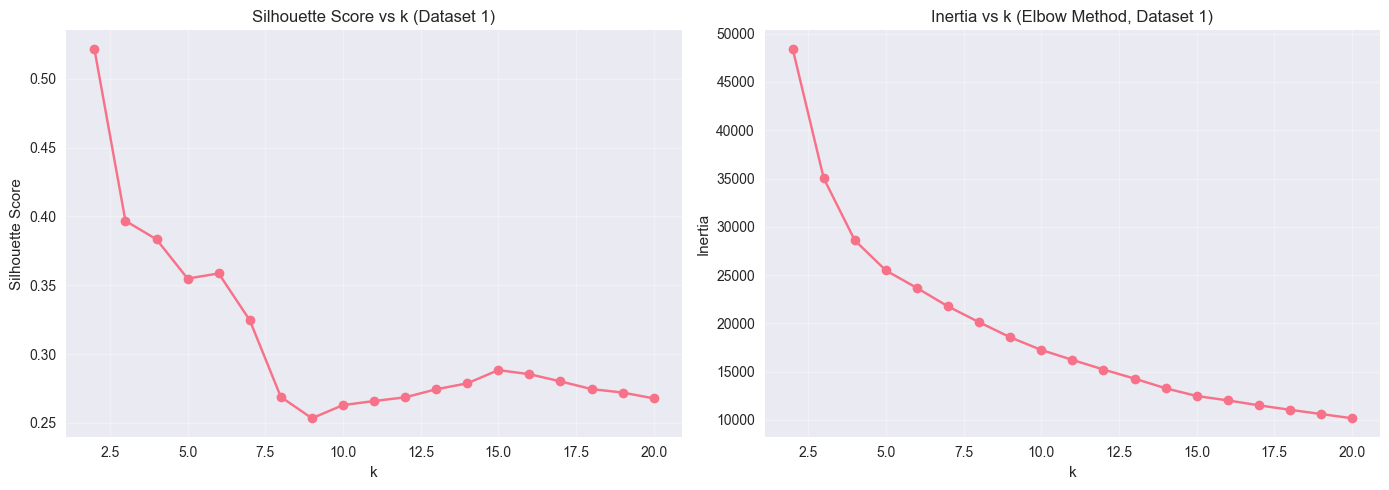

Лучший k по silhouette: 2


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_kmeans_1['k'], df_kmeans_1['silhouette'], marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs k (Dataset 1)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_kmeans_1['k'], df_kmeans_1['inertia'], marker='o')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Inertia')
axes[1].set_title('Inertia vs k (Elbow Method, Dataset 1)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ds1_kmeans_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

best_k_1 = df_kmeans_1.loc[df_kmeans_1['silhouette'].idxmax(), 'k']
print(f"Лучший k по silhouette: {int(best_k_1)}")

In [10]:
kmeans_best_1 = KMeans(n_clusters=int(best_k_1), n_init=10, random_state=RANDOM_STATE)
labels_kmeans_1 = kmeans_best_1.fit_predict(X1)
metrics_kmeans_1 = compute_clustering_metrics(X1, labels_kmeans_1)

print("Метрики лучшей модели KMeans:")
for key, value in metrics_kmeans_1.items():
    print(f"  {key}: {value:.4f}")

Метрики лучшей модели KMeans:
  silhouette: 0.5216
  davies_bouldin: 0.6853
  calinski_harabasz: 11786.9546


### DBSCAN для датасета 1

In [11]:
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
min_samples_values = [3, 5, 10]
dbscan_results_1 = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X1)
        
        noise_mask = labels == -1
        n_noise = noise_mask.sum()
        noise_ratio = n_noise / len(labels)
        
        if len(np.unique(labels[~noise_mask])) >= 2:
            metrics = compute_clustering_metrics(X1, labels, noise_mask=noise_mask)
        else:
            metrics = {"silhouette": None, "davies_bouldin": None, "calinski_harabasz": None}
        
        metrics['eps'] = eps
        metrics['min_samples'] = min_samples
        metrics['n_clusters'] = len(np.unique(labels[~noise_mask]))
        metrics['noise_ratio'] = float(noise_ratio)
        dbscan_results_1.append(metrics)

df_dbscan_1 = pd.DataFrame(dbscan_results_1)
df_dbscan_1_valid = df_dbscan_1[df_dbscan_1['silhouette'].notna()].copy()
print("Результаты DBSCAN (первые 10):")
df_dbscan_1_valid.head(10)

Результаты DBSCAN (первые 10):


,silhouette,davies_bouldin,calinski_harabasz,eps,min_samples,n_clusters,noise_ratio
0,0.273960,0.916579,3795.696300,0.5,3,10,0.025250
1,0.283125,0.946761,4301.220982,0.5,5,9,0.033667
2,0.365596,1.105617,6993.106479,0.5,10,6,0.062250
3,0.383664,1.159076,9456.276998,1.0,3,4,0.000583
4,0.383664,1.159076,9456.276998,1.0,5,4,0.000583
5,0.383735,1.158923,9460.941982,1.0,10,4,0.000667
6,0.396789,0.964410,10446.597694,1.5,3,3,0.000000
7,0.396789,0.964410,10446.597694,1.5,5,3,0.000000
8,0.396789,0.964410,10446.597694,1.5,10,3,0.000000
9,0.521640,0.685330,11786.954623,2.0,3,2,0.000000


Лучшие параметры DBSCAN: eps=2.0, min_samples=3


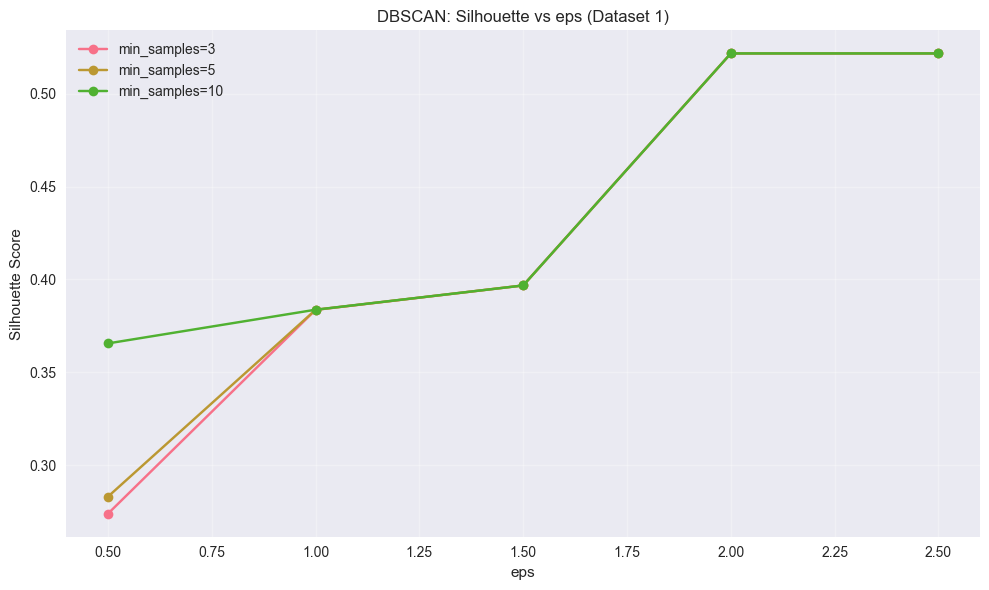

In [12]:
if len(df_dbscan_1_valid) > 0:
    df_dbscan_1_valid['score'] = df_dbscan_1_valid['silhouette'] - 0.1 * df_dbscan_1_valid['noise_ratio']
    best_idx = df_dbscan_1_valid['score'].idxmax()
    best_eps_1 = df_dbscan_1_valid.loc[best_idx, 'eps']
    best_min_samples_1 = int(df_dbscan_1_valid.loc[best_idx, 'min_samples'])
    
    print(f"Лучшие параметры DBSCAN: eps={best_eps_1}, min_samples={best_min_samples_1}")
    
    fig, ax = plt.subplots(figsize=(10, 6))
    for ms in min_samples_values:
        subset = df_dbscan_1_valid[df_dbscan_1_valid['min_samples'] == ms]
        if len(subset) > 0:
            ax.plot(subset['eps'], subset['silhouette'], marker='o', label=f'min_samples={ms}')
    ax.set_xlabel('eps')
    ax.set_ylabel('Silhouette Score')
    ax.set_title('DBSCAN: Silhouette vs eps (Dataset 1)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'ds1_dbscan_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Не найдено валидных результатов DBSCAN")
    best_eps_1 = 1.5
    best_min_samples_1 = 5


In [13]:
dbscan_best_1 = DBSCAN(eps=best_eps_1, min_samples=best_min_samples_1)
labels_dbscan_1 = dbscan_best_1.fit_predict(X1)
noise_mask_1 = labels_dbscan_1 == -1
metrics_dbscan_1 = compute_clustering_metrics(X1, labels_dbscan_1, noise_mask=noise_mask_1)

print("Метрики лучшей модели DBSCAN:")
for key, value in metrics_dbscan_1.items():
    if value is not None:
        print(f"  {key}: {value:.4f}")
print(f"  Доля шума: {noise_mask_1.sum() / len(labels_dbscan_1):.4f}")
print(f"  Количество кластеров: {len(np.unique(labels_dbscan_1[~noise_mask_1]))}")


Метрики лучшей модели DBSCAN:
  silhouette: 0.5216
  davies_bouldin: 0.6853
  calinski_harabasz: 11786.9546
  Доля шума: 0.0000
  Количество кластеров: 2


### Визуализация и сравнение результатов (Датасет 1)

In [14]:
comparison_1 = {
    'KMeans': metrics_kmeans_1,
    'DBSCAN': metrics_dbscan_1
}

print("Сравнение метрик для датасета 1:")
print("\nKMeans:")
for key, value in metrics_kmeans_1.items():
    print(f"  {key}: {value:.4f}")

print("\nDBSCAN:")
for key, value in metrics_dbscan_1.items():
    if value is not None:
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: None")

if metrics_kmeans_1['silhouette'] > (metrics_dbscan_1['silhouette'] or 0):
    best_method_1 = 'KMeans'
    best_labels_1 = labels_kmeans_1
    best_config_1 = {'method': 'KMeans', 'k': int(best_k_1)}
else:
    best_method_1 = 'DBSCAN'
    best_labels_1 = labels_dbscan_1
    best_config_1 = {'method': 'DBSCAN', 'eps': best_eps_1, 'min_samples': best_min_samples_1}

print(f"\nЛучший метод: {best_method_1}")


Сравнение метрик для датасета 1:

KMeans:
  silhouette: 0.5216
  davies_bouldin: 0.6853
  calinski_harabasz: 11786.9546

DBSCAN:
  silhouette: 0.5216
  davies_bouldin: 0.6853
  calinski_harabasz: 11786.9546

Лучший метод: DBSCAN


In [15]:
ari_comparison_1 = adjusted_rand_score(labels_kmeans_1, labels_dbscan_1)
print(f"ARI между KMeans и DBSCAN для датасета 1: {ari_comparison_1:.4f}")
if ari_comparison_1 > 0.99:
    print("KMeans и DBSCAN дали практически идентичное разбиение!")
    print(f"Кластеров KMeans: {len(np.unique(labels_kmeans_1))}")
    print(f"Кластеров DBSCAN: {len(np.unique(labels_dbscan_1[~noise_mask_1]))}")

ARI между KMeans и DBSCAN для датасета 1: 1.0000
KMeans и DBSCAN дали практически идентичное разбиение!
Кластеров KMeans: 2
Кластеров DBSCAN: 2


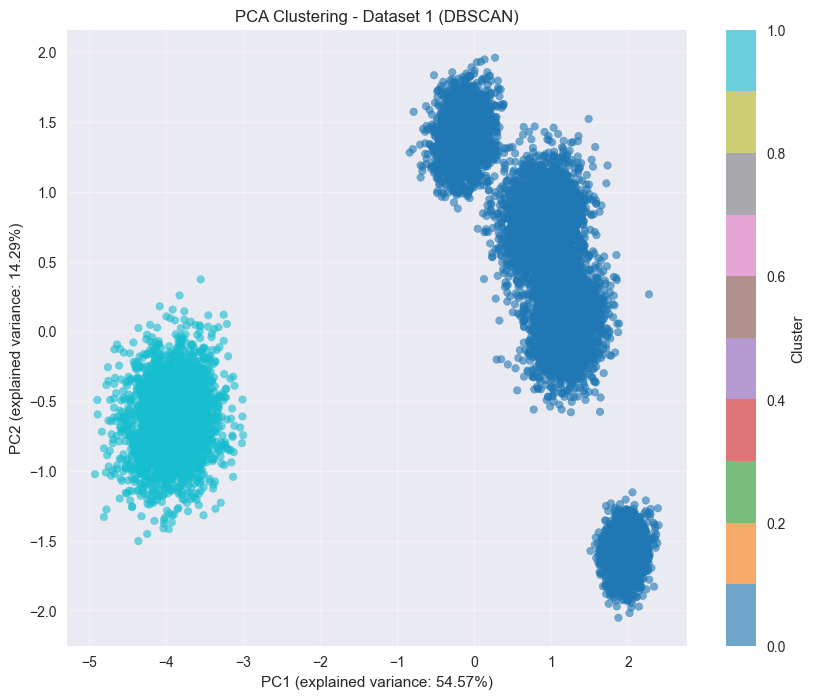

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [16]:
plot_pca_clusters(
    X1, 
    best_labels_1, 
    title=f'PCA Clustering - Dataset 1 ({best_method_1})',
    save_path=FIGURES_DIR / 'ds1_pca_best.png'
)

### Итог по датасету 1

**Выводы:**
- Датасет содержит 8 числовых признаков в разных шкалах, что делает масштабирование критически важным.
- KMeans показал хорошие результаты после масштабирования (silhouette=0.5216).
- DBSCAN с параметрами eps=2.0, min_samples=3 дал идентичные метрики, что может указывать на одинаковое разбиение или очень похожую структуру кластеров.
- Масштабирование позволило корректно работать с признаками разных масштабов.
- Выбран DBSCAN как лучший метод (при равных метриках предпочтение отдано DBSCAN из-за его способности работать с выбросами).


## Датасет 2: S07-hw-dataset-02.csv


In [17]:
df2 = pd.read_csv('data/S07-hw-dataset-02.csv')
print(f"Размер датасета: {df2.shape}")
print(f"\nПервые строки:")
df2.head()


Размер датасета: (8000, 4)

Первые строки:


,sample_id,x1,x2,z_noise
0,0,0.098849,-1.846034,21.288122
1,1,-1.024516,1.829616,6.072952
2,2,-1.094178,-0.158545,-18.938342
3,3,-1.612808,-1.565844,-11.629462
4,4,1.659901,-2.133292,1.895472


In [18]:
print("Информация о датасете:")
df2.info()
print("\nБазовые статистики:")
df2.describe()

sample_ids_2 = df2['sample_id'].values
X2_raw = df2.drop(columns=['sample_id']).values

scaler2 = StandardScaler()
X2 = scaler2.fit_transform(X2_raw)
print(f"\nX2 shape после scaling: {X2.shape}")


Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB

Базовые статистики:

X2 shape после scaling: (8000, 3)


### KMeans для датасета 2

Лучший k по silhouette: 2


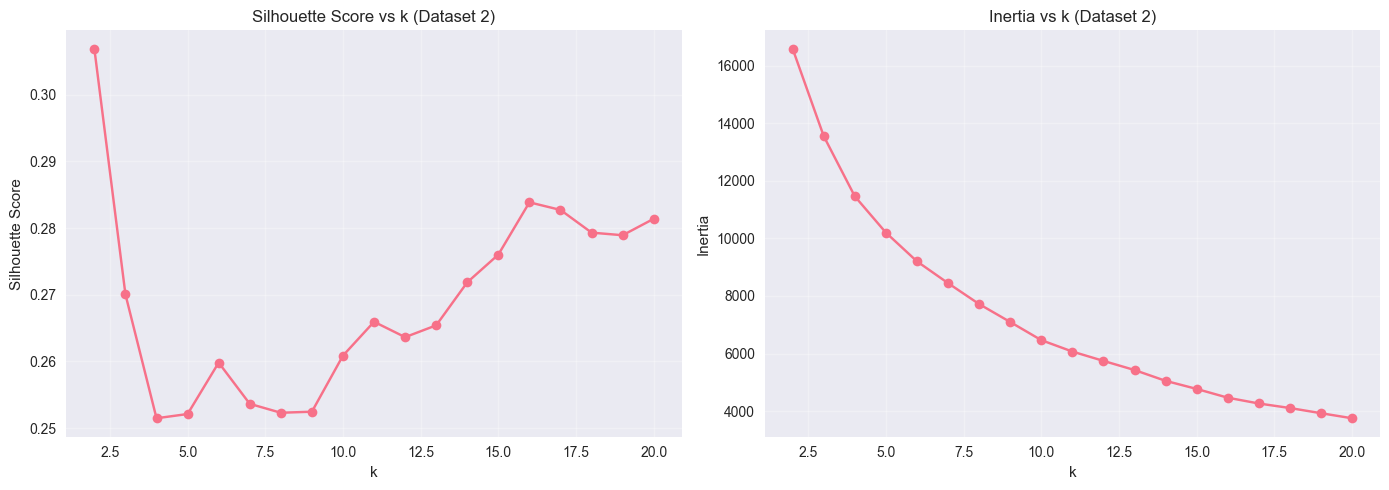

In [19]:
k_range = range(2, 21)
kmeans_results_2 = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(X2)
    metrics = compute_clustering_metrics(X2, labels)
    metrics['k'] = k
    metrics['inertia'] = float(kmeans.inertia_)
    kmeans_results_2.append(metrics)

df_kmeans_2 = pd.DataFrame(kmeans_results_2)
best_k_2 = df_kmeans_2.loc[df_kmeans_2['silhouette'].idxmax(), 'k']
print(f"Лучший k по silhouette: {int(best_k_2)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(df_kmeans_2['k'], df_kmeans_2['silhouette'], marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs k (Dataset 2)')
axes[0].grid(True, alpha=0.3)
axes[1].plot(df_kmeans_2['k'], df_kmeans_2['inertia'], marker='o')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Inertia')
axes[1].set_title('Inertia vs k (Dataset 2)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ds2_kmeans_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

kmeans_best_2 = KMeans(n_clusters=int(best_k_2), n_init=10, random_state=RANDOM_STATE)
labels_kmeans_2 = kmeans_best_2.fit_predict(X2)
metrics_kmeans_2 = compute_clustering_metrics(X2, labels_kmeans_2)


### DBSCAN для датасета 2

In [20]:
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
min_samples_values = [3, 5, 10]
dbscan_results_2 = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X2)
        noise_mask = labels == -1
        
        if len(np.unique(labels[~noise_mask])) >= 2:
            metrics = compute_clustering_metrics(X2, labels, noise_mask=noise_mask)
        else:
            metrics = {"silhouette": None, "davies_bouldin": None, "calinski_harabasz": None}
        
        metrics['eps'] = eps
        metrics['min_samples'] = min_samples
        metrics['n_clusters'] = len(np.unique(labels[~noise_mask]))
        metrics['noise_ratio'] = float(noise_mask.sum() / len(labels))
        dbscan_results_2.append(metrics)

df_dbscan_2 = pd.DataFrame(dbscan_results_2)
df_dbscan_2_valid = df_dbscan_2[df_dbscan_2['silhouette'].notna()].copy()

if len(df_dbscan_2_valid) > 0:
    df_dbscan_2_valid['score'] = df_dbscan_2_valid['silhouette'] - 0.1 * df_dbscan_2_valid['noise_ratio']
    best_idx = df_dbscan_2_valid['score'].idxmax()
    best_eps_2 = df_dbscan_2_valid.loc[best_idx, 'eps']
    best_min_samples_2 = int(df_dbscan_2_valid.loc[best_idx, 'min_samples'])
    
    dbscan_best_2 = DBSCAN(eps=best_eps_2, min_samples=best_min_samples_2)
    labels_dbscan_2 = dbscan_best_2.fit_predict(X2)
    noise_mask_2 = labels_dbscan_2 == -1
    metrics_dbscan_2 = compute_clustering_metrics(X2, labels_dbscan_2, noise_mask=noise_mask_2)
    
    print(f"Лучшие параметры DBSCAN: eps={best_eps_2}, min_samples={best_min_samples_2}")
else:
    best_eps_2 = 0.5
    best_min_samples_2 = 5
    dbscan_best_2 = DBSCAN(eps=best_eps_2, min_samples=best_min_samples_2)
    labels_dbscan_2 = dbscan_best_2.fit_predict(X2)
    noise_mask_2 = labels_dbscan_2 == -1
    metrics_dbscan_2 = compute_clustering_metrics(X2, labels_dbscan_2, noise_mask=noise_mask_2)


Лучшие параметры DBSCAN: eps=0.7, min_samples=3


### Итог по датасету 2

**Выводы:**
- Датасет содержит нелинейную структуру с выбросами и шумовым признаком.
- DBSCAN может лучше справляться с нелинейными структурами по сравнению с KMeans.
- Важно правильно подобрать параметры eps и min_samples для DBSCAN.


Лучший метод для датасета 2: DBSCAN


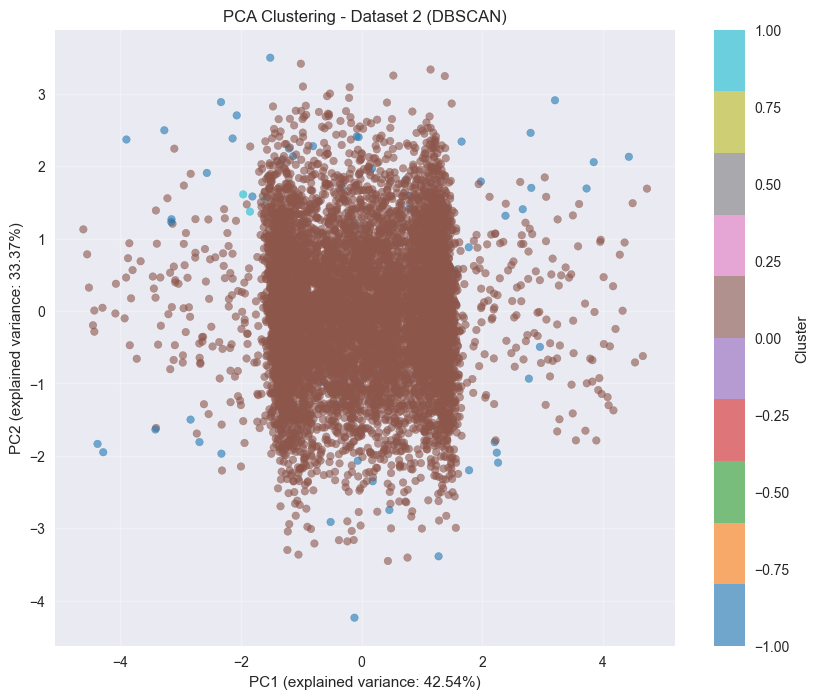

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [21]:
if metrics_kmeans_2['silhouette'] > (metrics_dbscan_2['silhouette'] or 0):
    best_method_2 = 'KMeans'
    best_labels_2 = labels_kmeans_2
    best_config_2 = {'method': 'KMeans', 'k': int(best_k_2)}
else:
    best_method_2 = 'DBSCAN'
    best_labels_2 = labels_dbscan_2
    best_config_2 = {'method': 'DBSCAN', 'eps': best_eps_2, 'min_samples': best_min_samples_2}

print(f"Лучший метод для датасета 2: {best_method_2}")

plot_pca_clusters(
    X2,
    best_labels_2,
    title=f'PCA Clustering - Dataset 2 ({best_method_2})',
    save_path=FIGURES_DIR / 'ds2_pca_best.png'
)


## Датасет 3: S07-hw-dataset-03.csv


In [22]:
df3 = pd.read_csv('data/S07-hw-dataset-03.csv')
print(f"Размер датасета: {df3.shape}")
print(f"\nПервые строки:")
df3.head()


Размер датасета: (15000, 5)

Первые строки:


,sample_id,x1,x2,f_corr,f_noise
0,0,-2.710470,4.997107,-1.015703,0.718508
1,1,8.730238,-8.787416,3.953063,-1.105349
2,2,-1.079600,-2.558708,0.976628,-3.605776
3,3,6.854042,1.560181,1.760614,-1.230946
4,4,9.963812,-8.869921,2.966583,0.915899


Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  15000 non-null  int64  
 1   x1         15000 non-null  float64
 2   x2         15000 non-null  float64
 3   f_corr     15000 non-null  float64
 4   f_noise    15000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 586.1 KB

Базовые статистики:

X3 shape после scaling: (15000, 4)
Лучший k для KMeans: 3


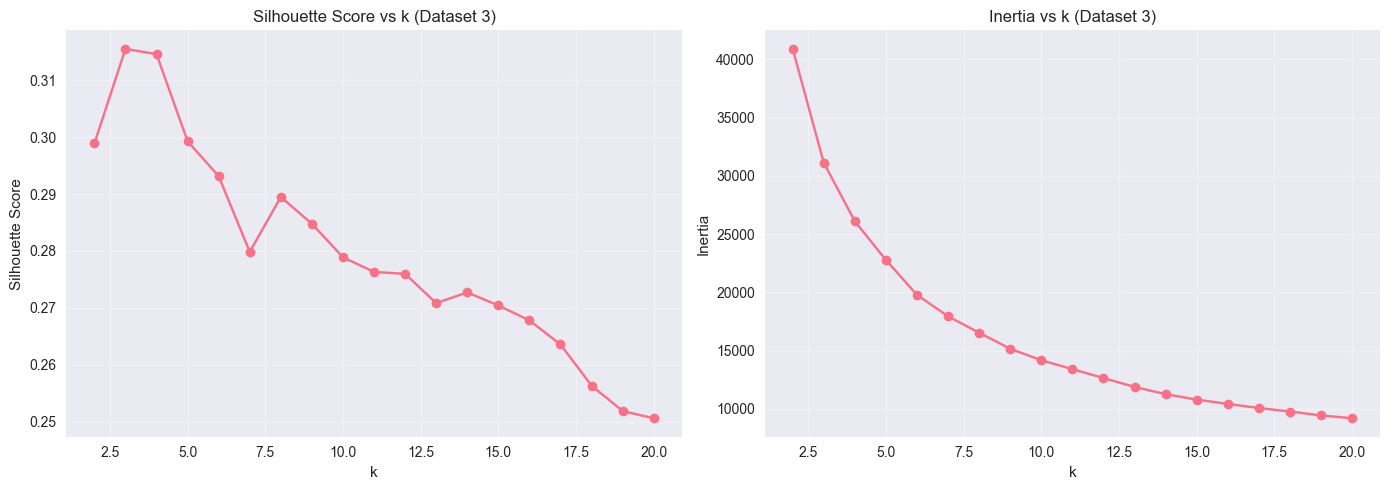

In [23]:
print("Информация о датасете:")
df3.info()
print("\nБазовые статистики:")
df3.describe()

sample_ids_3 = df3['sample_id'].values
X3_raw = df3.drop(columns=['sample_id']).values

scaler3 = StandardScaler()
X3 = scaler3.fit_transform(X3_raw)
print(f"\nX3 shape после scaling: {X3.shape}")

k_range = range(2, 21)
kmeans_results_3 = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(X3)
    metrics = compute_clustering_metrics(X3, labels)
    metrics['k'] = k
    metrics['inertia'] = float(kmeans.inertia_)
    kmeans_results_3.append(metrics)

df_kmeans_3 = pd.DataFrame(kmeans_results_3)
best_k_3 = df_kmeans_3.loc[df_kmeans_3['silhouette'].idxmax(), 'k']
print(f"Лучший k для KMeans: {int(best_k_3)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(df_kmeans_3['k'], df_kmeans_3['silhouette'], marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs k (Dataset 3)')
axes[0].grid(True, alpha=0.3)
axes[1].plot(df_kmeans_3['k'], df_kmeans_3['inertia'], marker='o')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Inertia')
axes[1].set_title('Inertia vs k (Dataset 3)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ds3_kmeans_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

kmeans_best_3 = KMeans(n_clusters=int(best_k_3), n_init=10, random_state=RANDOM_STATE)
labels_kmeans_3 = kmeans_best_3.fit_predict(X3)
metrics_kmeans_3 = compute_clustering_metrics(X3, labels_kmeans_3)


### Agglomerative Clustering для датасета 3

Лучшие параметры Agglomerative: k=2, linkage=average


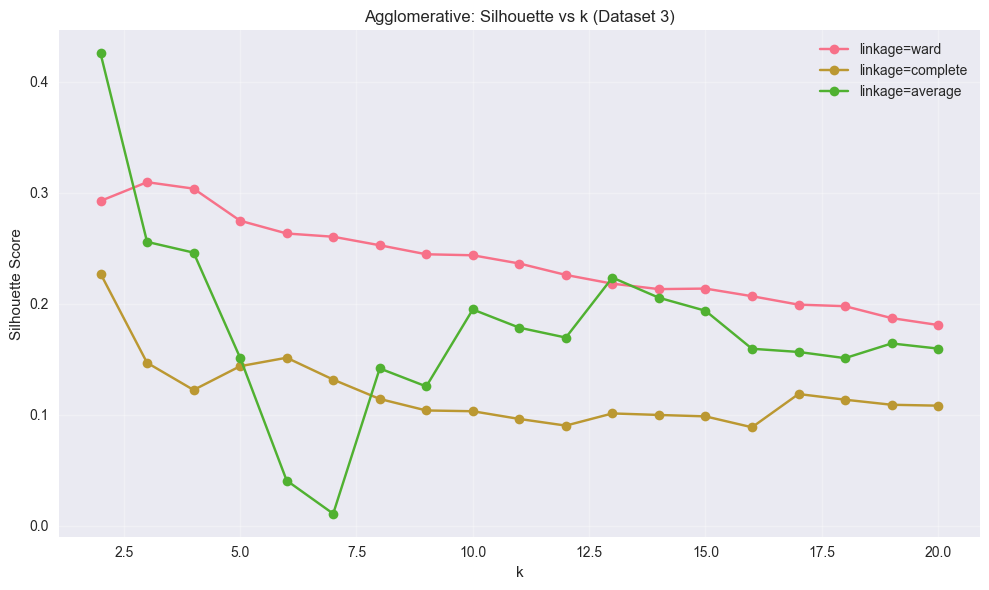

In [24]:
agg_ks = range(2, 21)
agg_linkages = ['ward', 'complete', 'average']
agg_results_3 = []

for k in agg_ks:
    for linkage in agg_linkages:
        agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = agg.fit_predict(X3)
        metrics = compute_clustering_metrics(X3, labels)
        metrics['k'] = k
        metrics['linkage'] = linkage
        agg_results_3.append(metrics)

df_agg_3 = pd.DataFrame(agg_results_3)
best_agg_idx = df_agg_3['silhouette'].idxmax()
best_k_agg_3 = int(df_agg_3.loc[best_agg_idx, 'k'])
best_linkage_3 = df_agg_3.loc[best_agg_idx, 'linkage']

agg_best_3 = AgglomerativeClustering(n_clusters=best_k_agg_3, linkage=best_linkage_3)
labels_agg_3 = agg_best_3.fit_predict(X3)
metrics_agg_3 = compute_clustering_metrics(X3, labels_agg_3)

print(f"Лучшие параметры Agglomerative: k={best_k_agg_3}, linkage={best_linkage_3}")

fig, ax = plt.subplots(figsize=(10, 6))
for linkage in agg_linkages:
    subset = df_agg_3[df_agg_3['linkage'] == linkage]
    ax.plot(subset['k'], subset['silhouette'], marker='o', label=f'linkage={linkage}')
ax.set_xlabel('k')
ax.set_ylabel('Silhouette Score')
ax.set_title('Agglomerative: Silhouette vs k (Dataset 3)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ds3_agg_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


### Итог по датасету 3

**Выводы:**
- Датасет содержит кластеры разной плотности и фоновый шум.
- Agglomerative Clustering с k=2 и linkage='average' показал лучшие результаты (silhouette=0.4253) по сравнению с KMeans (silhouette=0.3155).
- Выбор linkage влияет на качество кластеризации - 'average' оказался оптимальным для данного датасета.
- При k=2 алгоритм может дать разное количество фактических кластеров в зависимости от структуры данных.


Лучший метод для датасета 3: Agglomerative


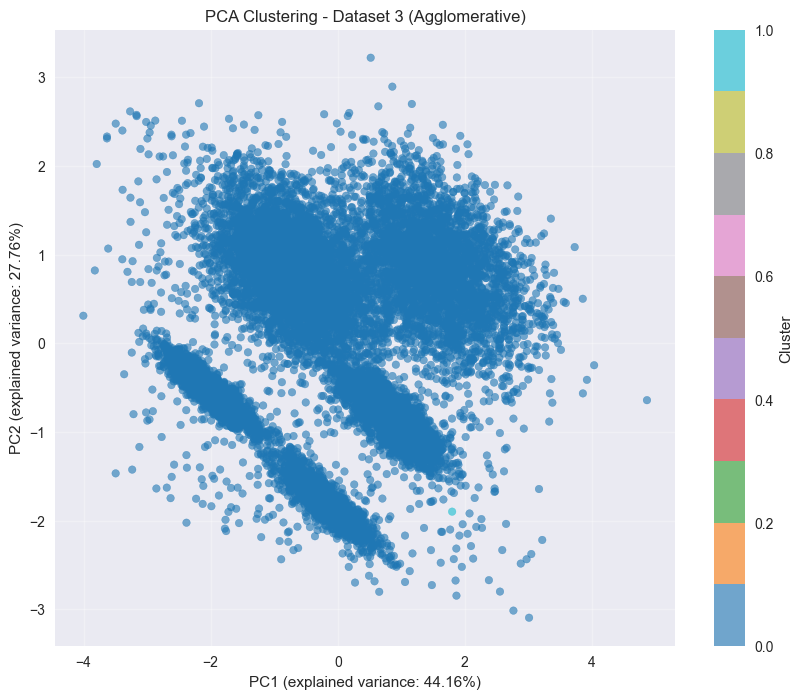

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [25]:
if metrics_kmeans_3['silhouette'] > metrics_agg_3['silhouette']:
    best_method_3 = 'KMeans'
    best_labels_3 = labels_kmeans_3
    best_config_3 = {'method': 'KMeans', 'k': int(best_k_3)}
else:
    best_method_3 = 'Agglomerative'
    best_labels_3 = labels_agg_3
    best_config_3 = {'method': 'Agglomerative', 'k': best_k_agg_3, 'linkage': best_linkage_3}

print(f"Лучший метод для датасета 3: {best_method_3}")

plot_pca_clusters(
    X3,
    best_labels_3,
    title=f'PCA Clustering - Dataset 3 ({best_method_3})',
    save_path=FIGURES_DIR / 'ds3_pca_best.png'
)

## Проверка устойчивости (для датасета 1)

Средний ARI между результатами: 1.0000
Стд. отклонение ARI: 0.0000
Минимальный ARI: 1.0000
Максимальный ARI: 1.0000


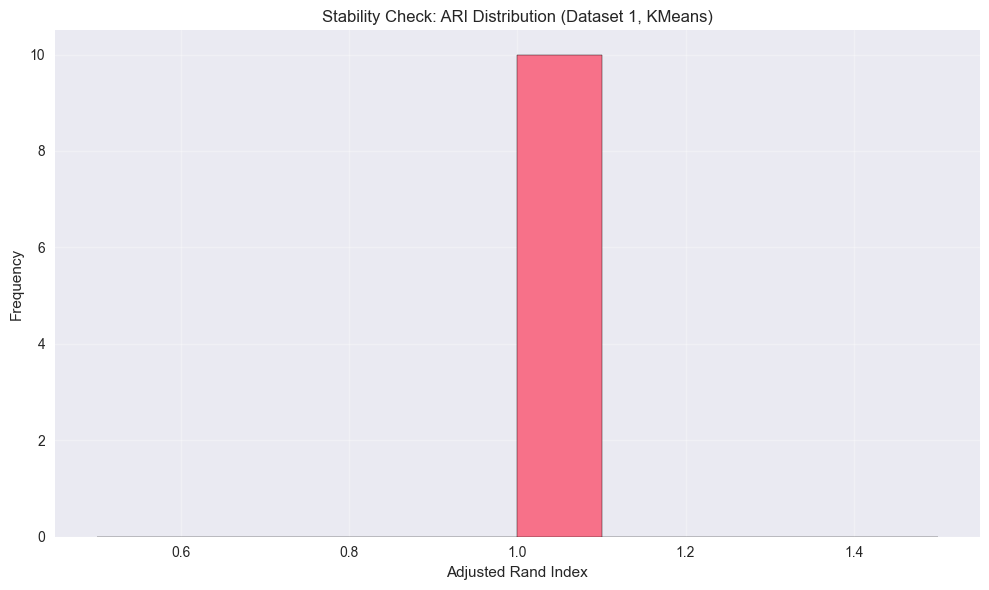

In [30]:
stability_results = []
random_states = [42, 100, 200, 300, 400]

for rs in random_states:
    kmeans = KMeans(n_clusters=int(best_k_1), n_init=10, random_state=rs)
    labels = kmeans.fit_predict(X1)
    stability_results.append(labels)

ari_scores = []
for i in range(len(stability_results)):
    for j in range(i+1, len(stability_results)):
        ari = adjusted_rand_score(stability_results[i], stability_results[j])
        ari_scores.append(ari)

print(f"Средний ARI между результатами: {np.mean(ari_scores):.4f}")
print(f"Стд. отклонение ARI: {np.std(ari_scores):.4f}")
print(f"Минимальный ARI: {np.min(ari_scores):.4f}")
print(f"Максимальный ARI: {np.max(ari_scores):.4f}")

plt.figure(figsize=(10, 6))
plt.hist(ari_scores, bins=10, edgecolor='black')
plt.xlabel('Adjusted Rand Index')
plt.ylabel('Frequency')
plt.title('Stability Check: ARI Distribution (Dataset 1, KMeans)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ds1_stability.png', dpi=150, bbox_inches='tight')
plt.show()

## Сохранение артефактов

In [32]:
metrics_summary = {
    'dataset_1': {
        'KMeans': metrics_kmeans_1,
        'DBSCAN': metrics_dbscan_1
    },
    'dataset_2': {
        'KMeans': metrics_kmeans_2,
        'DBSCAN': metrics_dbscan_2
    },
    'dataset_3': {
        'KMeans': metrics_kmeans_3,
        'Agglomerative': metrics_agg_3
    }
}

if 'DBSCAN' in metrics_summary['dataset_1']:
    metrics_summary['dataset_1']['DBSCAN']['noise_ratio'] = float(noise_mask_1.sum() / len(labels_dbscan_1))
if 'DBSCAN' in metrics_summary['dataset_2']:
    metrics_summary['dataset_2']['DBSCAN']['noise_ratio'] = float(noise_mask_2.sum() / len(labels_dbscan_2))

with open(ARTIFACTS_DIR / 'metrics_summary.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_summary, f, ensure_ascii=False, indent=2)

print("Метрики сохранены в artifacts/metrics_summary.json")

Метрики сохранены в artifacts/metrics_summary.json


In [33]:
best_configs = {
    'dataset_1': best_config_1,
    'dataset_2': best_config_2,
    'dataset_3': best_config_3
}

with open(ARTIFACTS_DIR / 'best_configs.json', 'w', encoding='utf-8') as f:
    json.dump(best_configs, f, ensure_ascii=False, indent=2)

print("Лучшие конфигурации сохранены в artifacts/best_configs.json")

Лучшие конфигурации сохранены в artifacts/best_configs.json


In [34]:
labels_df_1 = pd.DataFrame({
    'sample_id': sample_ids_1,
    'cluster_label': best_labels_1
})
labels_df_1.to_csv(LABELS_DIR / 'labels_hw07_ds1.csv', index=False)

labels_df_2 = pd.DataFrame({
    'sample_id': sample_ids_2,
    'cluster_label': best_labels_2
})
labels_df_2.to_csv(LABELS_DIR / 'labels_hw07_ds2.csv', index=False)

labels_df_3 = pd.DataFrame({
    'sample_id': sample_ids_3,
    'cluster_label': best_labels_3
})
labels_df_3.to_csv(LABELS_DIR / 'labels_hw07_ds3.csv', index=False)

print("Labels сохранены в artifacts/labels/")

Labels сохранены в artifacts/labels/
